
TFG

Este es el codigo del tfg de Borja Jimeno

In [4]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos

import numpy as np
import math as m
import matplotlib.pyplot as plt
from scipy import special
from scipy.stats import norm
from scipy.interpolate import InterpolatedUnivariateSpline
import re

path="/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS"
sys.path.append(path)

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

plt.rcParams['font.size'] = 18

In [5]:
def rate_IP(ene,data,E):
   f_interp=InterpolatedUnivariateSpline(ene,data)
   return f_interp(E)

def rate_EP(ene,data,Eee,t,Q=1):
    E=Eee/Q
    retval=rate_IP(ene,data,E)
    retval/=Q
    return retval

def rateNaI_EP(ene_I,ene_Na,data_I,data_Na,Eee,QNa=1, QI=1):
  # convert Eee to keV_NR
  rateNa = rate_EP(ene_Na,data_Na,Eee,QNa)
  rateI = rate_EP(ene_I,data_I,Eee,QI)
 
  return (rateNa*23.+rateI*127.)/(23.+127.)

def totalRate_EP(ene_I,ene_Na,data_I,data_Na,Eiee,Efee):
  energy_ee = np.arange(Eiee,Efee,0.1)
  qfNa = getQFNa(energy_ee)
  qfI = getQFI(energy_ee)
  rates = np.array([
        rateNaI_EP(ene_I,ene_Na,data_I,data_Na,e,qna, qi)
        for e, qna, qi in zip(energy_ee, qfNa, qfI)
    ])
  return rates.sum()*0.1

def numero_cuentas_teo_EP(ene_I,ene_Na,data_I,data_Na,Eiee,Efee,array_det=np.ones(9,dtype=int)):
  Matriz=np.eye(9)
  exp=0
  for i in range(9):
          if(array_det[i]==1):
            texp=calcula_t_exposicion(i)
            mexp=calcula_m_exposicion(i)
            exp+=texp*mexp
  retval=totalRate_EP(ene_I,ene_Na,data_I,data_Na,Eiee,Efee)
  return retval*exp

def calcula_sigma_EP(ene_I,ene_Na,data_I,data_Na,E_i,E_f,cl=0.9,array_det=np.ones(9,dtype=int)):
    N_teo=numero_cuentas_teo_EP(ene_I,ene_Na,data_I,data_Na,E_i,E_f,array_det)
    N_exp=numero_cuentas_exp_CL(E_i,E_f,cl,array_det)
    return N_exp/N_teo
    

In [6]:
mw = []
for imw in range(2, 10):  # range(2,10) genera 2,3,4,5,6,7,8,9
    for j in range(4):  # j = 0,1,2,3
        a = float(imw + 0.2 * j)
        mw.append(a)
for imw in range(1, 10):  # range(1,10) genera 1,2,3,4,5,6,7,8,9
    for j in range(4):
        a = float(imw + 0.2 * j)
        mw.append(a * 10)
for imw in range(1, 10):
    for j in range(4):
        a = float(imw + 0.2 * j)
        mw.append(a * 100)
for imw in range(1, 11):  # range(1,11) genera 1,2,3,4,5,6,7,8,9,10
    for j in range(4):
        a = float(imw + 0.2 * j)
        mw.append(a * 1000)
mWs=np.array(mw)
#print(mWs)

In [7]:
Ei=1
Ef=6

sigmas_DM=np.zeros(len(mWs))
sigmas_DM_2=np.zeros(len(mWs))
sigmas_PY=np.zeros(len(mWs))
sigmas_WY=np.zeros(len(mWs))
sigmas_RA=np.zeros(len(mWs))


for i in range (len(mWs)):
    mW=mWs[i]
    name2="rateDMAnalysis_SI_separados.root"
    file = uproot.open(name2)
    name="SI_rates/rate_SI_"
    name+="Na"
    name+="_mw"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_Na = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_Na = np.array(bin_centers)

    name2="rateDMAnalysis_SI_separados.root"
    file = uproot.open(name2)
    name="SI_rates/rate_SI_"
    name+="I"
    name+="_mw"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_I = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_I = np.array(bin_centers)

    sigmas_DM[i]=calcula_sigma_EP(ene_I,ene_Na,data_I,data_Na,Ei,Ef)



for i in range (len(mWs)):

    mW=mWs[i]

    name2="/home/borja/Documents/TFG/GeneraRitmo/Results/ANAIS_SI_TH1D.root"
    file = uproot.open(name2)

    name="hist_"
    name+="Na"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_Na = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_Na = np.array(bin_centers)

    name="hist_"
    name+="I"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_I = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_I = np.array(bin_centers)

    sigmas_PY[i]=calcula_sigma_EP(ene_I,ene_Na,data_I,data_Na,Ei,Ef)

for i in range (len(mWs)):

    mW=mWs[i]

    name2="/home/borja/Documents/TFG/GeneraRitmo/Results/RAPIDD_SI_TH1D.root"
    file = uproot.open(name2)

    name="hist_"
    name+="Na"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_Na = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_Na = np.array(bin_centers)

    name="hist_"
    name+="I"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_I = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_I = np.array(bin_centers)

    sigmas_RA[i]=calcula_sigma_EP(ene_I,ene_Na,data_I,data_Na,Ei,Ef)
for i in range (len(mWs)):

    mW=mWs[i]

    name2="/home/borja/Documents/TFG/GeneraRitmo/Results/WIMPYDD_SI_TH1D.root"
    file = uproot.open(name2)

    name="hist_"
    name+="Na"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_Na = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_Na = np.array(bin_centers)

    data_Na=np.delete(data_Na,0)
    ene_Na=np.delete(ene_Na,0)

    name="hist_"
    name+="I"
    name+="_mw_"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_I = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_I = np.array(bin_centers)

    data_I=np.delete(data_I,0)
    ene_I=np.delete(ene_I,0)

    sigmas_WY[i]=calcula_sigma_EP(ene_I,ene_Na,data_I,data_Na,Ei,Ef)

sigmas_DM*=1e-36 
sigmas_DM_2*=1e-36 
sigmas_PY*=1e-36 
sigmas_RA*=1e-36 
sigmas_WY*=1e-36 



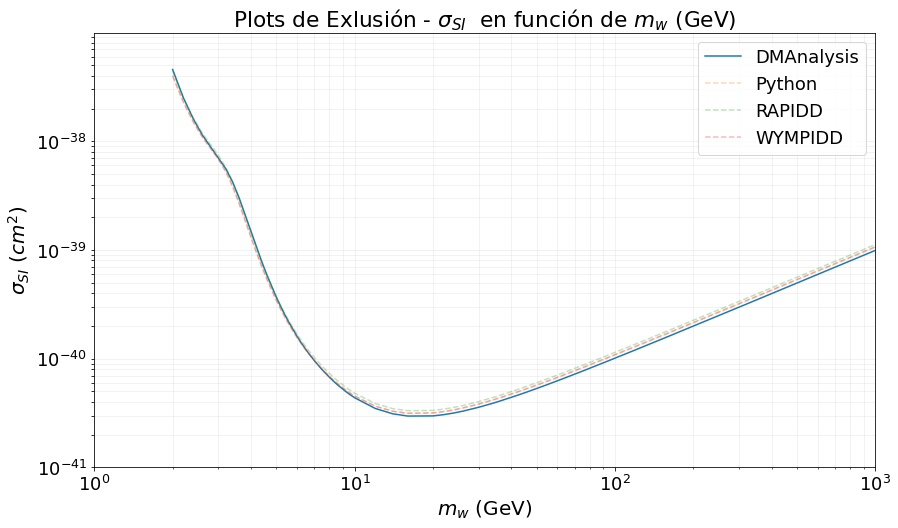

In [8]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()

ax.plot(mWs,sigmas_DM,label="DMAnalysis")

ax.plot(mWs,sigmas_PY,linestyle="--",label="Python",alpha=0.3)
ax.plot(mWs,sigmas_RA,linestyle="--",label="RAPIDD",alpha=0.3)
ax.plot(mWs,sigmas_WY,linestyle="--",label="WYMPIDD",alpha=0.3)


ax.legend()
ax.set_title(r'Plots de Exlusión - $\sigma_{SI}$  en función de $m_w$ (GeV)')
ax.set_ylabel(r'$\sigma_{SI}$ $(cm^2)$',fontsize=20)
ax.set_xlabel(r'$m_w$ (GeV)',fontsize=20)

ax.set_yscale("log")
ax.set_xscale("log")

y_sup=1e-37
y_inf=1e-41

ax.set_ylim(y_inf,y_sup)
ax.set_xlim(1,1000)

exp_min = int(np.floor(np.log10(y_inf)))   
exp_max = int(np.ceil(np.log10(y_sup)))    
exps = np.arange(exp_min, exp_max)     


all_ticks = []
for e in exps:
    decade = (np.arange(1, 10) * (10.0**e)).tolist()
    all_ticks.extend(decade)
all_ticks = np.array(all_ticks)

ax.set_yticks(all_ticks)                    

ax.grid(which='both', linestyle='-', alpha=0.2)